# Bible Structured Data Workflow

**Name:** Arturo Ramos
**Dataset:** BibleData — *Structured Datasets from the Holy Bible* (Brady Stephenson, 2026, CC BY 4.0) — https://github.com/BradyStephenson/bible-data (DOI: 10.5281/zenodo.19539956)

This project builds a reproducible data workflow over three structured tables of the Bible: the named people (`Person`), the verses in which each person appears (`PersonVerse`), and the 66 books (`Book`). I ingest and clean the tables, join them into a single tidy person–verse–book table, explore who is mentioned most and where, and visualize how mentions are distributed across people, books, and testaments. The result is a reusable foundation for the content pipeline of a Bible trivia application, where knowing which people appear in which chapters is needed to write well-anchored questions and plausible distractors.

## 1. Setup

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

print("numpy", np.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)

numpy 2.5.3 | pandas 3.0.6 | seaborn 0.13.2


## 2. Ingestion

The dataset ships as four CSV files. Before loading them I check the first bytes of each file: three of them start with a UTF-8 byte-order mark (`EF BB BF`), which is why every file is read with `encoding="utf-8-sig"` (it strips the mark when present and is harmless when it is not).

In [2]:
FILES = {
    "persons": DATA_DIR / "BibleData-Person.csv",
    "person_verse": DATA_DIR / "BibleData-PersonVerse.csv",
    "books": DATA_DIR / "BibleData-Book.csv",
    "events": DATA_DIR / "BibleData-Event.csv",
}
for name, path in FILES.items():
    head = path.read_bytes()[:3]
    print(f"{name:13s} {path.name:28s} first bytes: {head.hex()}  BOM: {head == b'\xef\xbb\xbf'}")

persons       BibleData-Person.csv         first bytes: 706572  BOM: False
person_verse  BibleData-PersonVerse.csv    first bytes: efbbbf  BOM: True
books         BibleData-Book.csv           first bytes: efbbbf  BOM: True
events        BibleData-Event.csv          first bytes: efbbbf  BOM: True


In [3]:
persons = pd.read_csv(FILES["persons"], encoding="utf-8-sig")
person_verse = pd.read_csv(FILES["person_verse"], encoding="utf-8-sig")
books = pd.read_csv(FILES["books"], encoding="utf-8-sig")
events = pd.read_csv(FILES["events"], encoding="utf-8-sig")

print("persons     ", persons.shape)
print("person_verse", person_verse.shape)
print("books       ", books.shape)
print("events      ", events.shape)
persons.head()

persons      (3009, 9)
person_verse (44267, 8)
books        (66, 18)
events       (572, 18)


,person_id,person_name,surname,unique_attribute,sex,tribe,person_notes,name_instance,person_sequence
0,YHVH_1,YHVH,NaN,"Holy, Holy, Holy (ISA 6:3) and too many others...",male,NaN,NaN,1,1
1,Adam_1,Adam,NaN,first man (1CO 15:45),male,NaN,NaN,1,2
2,Eve_1,Eve,NaN,"first woman, created from Adam (GEN 2:22)",female,NaN,NaN,1,3
3,Cain_1,Cain,NaN,"first son of Adam (GEN 4:1), cursed from the g...",male,NaN,NaN,1,4
4,Abel_1,Abel,NaN,"son of Adam(GEN 4:2), first person murdered (G...",male,NaN,NaN,1,5


In [4]:
person_verse.head()

,person_verse_id,reference_id,person_label_id,person_id,person_label,person_label_count,person_verse_sequence,person_verse_notes
0,GEN 1:1__YHVH_1_1,GEN 1:1,YHVH_1_1,YHVH_1,G-d,1.0,1,NaN
1,GEN 1:2__YHVH_1_1,GEN 1:2,YHVH_1_1,YHVH_1,G-d,1.0,2,NaN
2,GEN 1:3__YHVH_1_1,GEN 1:3,YHVH_1_1,YHVH_1,G-d,1.0,3,NaN
3,GEN 1:4__YHVH_1_1,GEN 1:4,YHVH_1_1,YHVH_1,G-d,1.0,4,NaN
4,GEN 1:5__YHVH_1_1,GEN 1:5,YHVH_1_1,YHVH_1,G-d,1.0,5,NaN


In [5]:
books[["book_name", "short_name", "usx_code", "christian_sequence", "chapter_count", "verse_count", "writer_id"]].head()

,book_name,short_name,usx_code,christian_sequence,chapter_count,verse_count,writer_id
0,Genesis,Gen,GEN,1,50,1533,Moses_1
1,Exodus,Exod,EXO,2,40,1213,Moses_1
2,Leviticus,Lev,LEV,3,27,859,Moses_1
3,Numbers,Num,NUM,4,36,1288,Moses_1
4,Deuteronomy,Deut,DEU,5,34,959,Moses_1


### Initial inspection

`info()` and the count of missing values per column reveal what the cleaning step has to deal with.

In [6]:
persons.info()
print()
print("Missing values per column (persons):")
print(persons.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3009 entries, 0 to 3008
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   person_id         3009 non-null   str  
 1   person_name       3009 non-null   str  
 2   surname           8 non-null      str  
 3   unique_attribute  3009 non-null   str  
 4   sex               3009 non-null   str  
 5   tribe             1608 non-null   str  
 6   person_notes      675 non-null    str  
 7   name_instance     3009 non-null   int64
 8   person_sequence   3009 non-null   int64
dtypes: int64(2), str(7)
memory usage: 211.7 KB

Missing values per column (persons):
person_id              0
person_name            0
surname             3001
unique_attribute       0
sex                    0
tribe               1401
person_notes        2334
name_instance          0
person_sequence        0
dtype: int64


In [7]:
print("Missing values per column (person_verse):")
print(person_verse.isna().sum())
print()
no_person = person_verse["person_id"].isna()
print(f"Rows without a person_id: {no_person.sum():,} of {len(person_verse):,}")
person_verse.loc[no_person].head(3)

Missing values per column (person_verse):
person_verse_id              0
reference_id                 0
person_label_id          14733
person_id                14733
person_label             14733
person_label_count       14733
person_verse_sequence        0
person_verse_notes       39506
dtype: int64

Rows without a person_id: 14,733 of 44,267


,person_verse_id,reference_id,person_label_id,person_id,person_label,person_label_count,person_verse_sequence,person_verse_notes
12,GEN 1:13__NA,GEN 1:13,NaN,NaN,NaN,NaN,13,NaN
14,GEN 1:15__NA,GEN 1:15,NaN,NaN,NaN,NaN,15,NaN
18,GEN 1:19__NA,GEN 1:19,NaN,NaN,NaN,NaN,19,NaN


In [8]:
# How ambiguous are names? `name_instance` numbers people who share the same name.
shared = persons.groupby("person_name")["person_id"].transform("size")
print(f"Names shared by more than one person: {(persons.groupby('person_name').size() > 1).sum():,}")
print(f"People whose name is shared with someone else: {(shared > 1).sum():,} of {len(persons):,}")
print(f"Largest name_instance: {persons['name_instance'].max()} ({persons.loc[persons['name_instance'].idxmax(), 'person_name']})")
persons.loc[persons["person_name"] == "Mary", ["person_id", "unique_attribute"]]

Names shared by more than one person: 482
People whose name is shared with someone else: 1,702 of 3,009
Largest name_instance: 23 (Zechariah)


,person_id,unique_attribute
2741,Mary_1,"wife of Joseph, and mother of the Messiah (MAT..."
2774,Mary_2,one of the women who followed Jesus from the G...
2841,Mary_3,sister of Martha (LUK 10:39)
2850,Mary_4,(the wife?) of Clopas (JHN 19:25)
2882,Mary_5,mother of John also called Mark (ACT 12:12)
2932,Mary_6,Mary of Rome of whom Paul wrote (ROM 16:6)


**What the inspection shows**

- Three of the four files carry a UTF-8 BOM; without `utf-8-sig` the first column name would be `\ufeffperson_verse_id` and later joins on that column would fail silently.
- `persons` has 3,009 rows. `surname` is missing in 3,001 rows (99.7 %), `person_notes` in 2,334 and `tribe` in 1,401 (46.6 %). `sex` is complete.
- `person_verse` has 44,267 rows, but 14,733 of them have no `person_id`: they are placeholder rows (`person_verse_id` ends in `__NA`) that mark verses in which no named person appears. They must be removed before counting mentions, otherwise every "mention" statistic is inflated.
- The verse reference lives in a single string (`GEN 1:1`). Book code, chapter and verse have to be parsed out of it before joining with `books` (`usx_code`) or grouping by chapter.
- Names are ambiguous: 482 names are shared by 1,702 people (there are six women called Mary and 23 people called Zechariah). `person_id` is the only safe key; deduplicating by name would merge different people.

## 3. Cleaning

Each cleaning step is a small function with a docstring so that it can be reused on a new release of the dataset.

In [9]:
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize column names: strip BOM characters and whitespace, lowercase, snake_case.

    Some BibleData CSVs start with a UTF-8 BOM (\ufeff). When a file is read without
    ``encoding="utf-8-sig"`` the mark ends up glued to the first column name and joins on
    that column fail silently. Normalizing names once makes the rest of the workflow robust
    to how the file was read.
    """
    out = df.copy()
    out.columns = (
        out.columns.str.replace("\ufeff", "", regex=False)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
    )
    return out


def clean_persons(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the Person table and return a tidy copy.

    - strips surrounding whitespace in ``person_name`` and ``unique_attribute``
    - drops ``surname`` (missing in 99.7 % of rows, so it carries almost no information)
    - fills missing ``tribe`` with ``"unknown"`` so that people without a recorded tribe are
      kept as a visible category instead of being silently dropped by group-bys
    - casts ``name_instance`` and ``person_sequence`` to ``int``
    - adds ``is_homonym``: True when the same ``person_name`` belongs to more than one person
    - drops exact duplicate rows and sorts by ``person_sequence``
    """
    out = df.copy()
    for col in ("person_name", "unique_attribute"):
        out[col] = out[col].astype("string").str.strip()
    out = out.drop(columns=["surname"])
    out["tribe"] = out["tribe"].fillna("unknown")
    out["name_instance"] = out["name_instance"].astype(int)
    out["person_sequence"] = out["person_sequence"].astype(int)
    out["is_homonym"] = out.groupby("person_name")["person_id"].transform("size") > 1
    out = out.drop_duplicates().sort_values("person_sequence").reset_index(drop=True)
    return out


def add_book_from_reference(df: pd.DataFrame, ref_col: str = "reference_id") -> pd.DataFrame:
    """Parse a reference like ``"GEN 24:20"`` into ``book_code``, ``chapter`` and ``verse``.

    ``book_code`` is the three-letter USX code used by BibleData (it matches ``usx_code`` in
    the Book table), ``chapter`` and ``verse`` are integers. Rows whose reference does not
    match the expected pattern would get missing values, so the function asserts that every
    reference was parsed.
    """
    out = df.copy()
    parts = out[ref_col].str.extract(r"^(?P<book_code>[1-3]?[A-Z]{2,3}) (?P<chapter>\d+):(?P<verse>\d+)$")
    assert parts.notna().all().all(), "some references do not match 'CODE chapter:verse'"
    out["book_code"] = parts["book_code"]
    out["chapter"] = parts["chapter"].astype(int)
    out["verse"] = parts["verse"].astype(int)
    return out


def clean_person_verse(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the PersonVerse table: keep only real mentions and parse the reference.

    - removes placeholder rows without ``person_id`` (they mark verses with no named person)
    - casts ``person_label_count`` to ``int``
    - drops ``person_verse_notes`` (free text present in a small minority of rows)
    - parses ``reference_id`` with :func:`add_book_from_reference`
    - drops duplicate (person, verse) pairs so that each row is one person in one verse
    """
    out = df.copy()
    out = out.loc[out["person_id"].notna()].copy()
    out["person_label_count"] = out["person_label_count"].astype(int)
    out = out.drop(columns=["person_verse_notes"])
    out = add_book_from_reference(out)
    out = out.drop_duplicates(subset=["person_id", "reference_id"]).reset_index(drop=True)
    return out


def attach_book_metadata(pv: pd.DataFrame, books_df: pd.DataFrame) -> pd.DataFrame:
    """Join book name, canonical order and testament onto a parsed person–verse table.

    The join key is the USX code (``book_code`` == ``usx_code``). ``testament`` is derived
    from the canonical Christian order: books 1–39 are the Old Testament, 40–66 the New
    Testament. The function asserts that every row found its book.
    """
    cols = ["usx_code", "book_name", "christian_sequence", "chapter_count", "verse_count"]
    out = pv.merge(books_df[cols], left_on="book_code", right_on="usx_code", how="left")
    assert out["book_name"].notna().all(), "some book codes did not match the Book table"
    out = out.drop(columns=["usx_code"])
    out["testament"] = np.where(out["christian_sequence"] <= 39, "OT", "NT")
    return out

In [10]:
persons_raw, person_verse_raw, books_raw = persons.copy(), person_verse.copy(), books.copy()

persons = clean_column_names(persons_raw)
person_verse = clean_column_names(person_verse_raw)
books = clean_column_names(books_raw)

persons_clean = clean_persons(persons)
person_verse_clean = clean_person_verse(person_verse)
pv = attach_book_metadata(person_verse_clean, books)

print(f"persons:      {persons_raw.shape} -> {persons_clean.shape}")
print(f"person_verse: {person_verse_raw.shape} -> {person_verse_clean.shape} (placeholders removed, repeated labels collapsed)")
print(f"pv (joined):  {pv.shape}")
print()
print("Missing values after cleaning (persons_clean):")
print(persons_clean.isna().sum())
pv.head()

persons:      (3009, 9) -> (3009, 9)
person_verse: (44267, 8) -> (27399, 10) (placeholders removed, repeated labels collapsed)
pv (joined):  (27399, 15)

Missing values after cleaning (persons_clean):
person_id              0
person_name            0
unique_attribute       0
sex                    0
tribe                  0
person_notes        2334
name_instance          0
person_sequence        0
is_homonym             0
dtype: int64


,person_verse_id,reference_id,person_label_id,person_id,person_label,person_label_count,person_verse_sequence,book_code,chapter,verse,book_name,christian_sequence,chapter_count,verse_count,testament
0,GEN 1:1__YHVH_1_1,GEN 1:1,YHVH_1_1,YHVH_1,G-d,1,1,GEN,1,1,Genesis,1,50,1533,OT
1,GEN 1:2__YHVH_1_1,GEN 1:2,YHVH_1_1,YHVH_1,G-d,1,2,GEN,1,2,Genesis,1,50,1533,OT
2,GEN 1:3__YHVH_1_1,GEN 1:3,YHVH_1_1,YHVH_1,G-d,1,3,GEN,1,3,Genesis,1,50,1533,OT
3,GEN 1:4__YHVH_1_1,GEN 1:4,YHVH_1_1,YHVH_1,G-d,1,4,GEN,1,4,Genesis,1,50,1533,OT
4,GEN 1:5__YHVH_1_1,GEN 1:5,YHVH_1_1,YHVH_1,G-d,1,5,GEN,1,5,Genesis,1,50,1533,OT


In [11]:
# Sanity checks on the cleaned tables
assert persons_clean["person_id"].is_unique
assert pv["person_id"].isin(persons_clean["person_id"]).all(), "every mention must point to a known person"
assert set(pv["testament"]) == {"OT", "NT"}
print("Distinct people mentioned:", pv["person_id"].nunique())
print("Distinct verses with at least one named person:", pv["reference_id"].nunique())
print("Books covered:", pv["book_name"].nunique())
print("Tribe values after fill (top 5):")
print(persons_clean["tribe"].value_counts().head())

Distinct people mentioned:

2993
Distinct verses with at least one named person: 16484
Books covered: 66
Tribe values after fill (top 5):
tribe
unknown     1401
Levi         608
Judah        338
Benjamin     208
Edomite       63
Name: count, dtype: int64


### Why these cleaning steps

- **Column names** (`clean_column_names`): three of the four files carry a BOM. Normalizing names protects every later `merge` and `groupby` from a column that looks like `person_id` but is actually `\ufeffperson_id`.
- **Placeholder rows** (`clean_person_verse`): the 14,733 rows without `person_id` are not missing data to impute; they are markers for verses with no named person. Keeping them would add 14,733 fake "mentions" and would break the join with `persons`. Removing them leaves 29,534 rows of real mentions; collapsing the 2,135 rows where the same person is labeled more than once in the same verse (for example "Jacob" and "Israel") leaves 27,399 unique person–verse pairs.
- **Reference parsing** (`add_book_from_reference`): `book_code`, `chapter` and `verse` are needed to join with `books` and to group by chapter. The regular expression is strict and the function asserts that all 29,534 references were parsed, so a malformed reference would surface as an error instead of a silent `NaN`.
- **Tribe** (`clean_persons`): 46.6 % of people have no recorded tribe. Filling with `"unknown"` keeps them in every group-by; dropping them would systematically remove people from books such as the Gospels, where tribe is rarely stated.
- **Surname**: missing in 99.7 % of rows, so it is dropped rather than imputed.
- **Homonyms** (`is_homonym`): 1,702 people share a name with someone else. All grouping is done on `person_id`, never on `person_name`; the flag makes the ambiguity visible when names are displayed.
- **Testament** (`attach_book_metadata`): derived from the canonical order instead of a hand-typed list, which avoids typos and works for any future release with the same 66 books.

## 4. Exploratory Data Analysis

Four small functions answer the questions that matter for a content pipeline: who is mentioned most, how mentions are distributed, how much of each book names anyone at all, and who appears in a given chapter.

In [12]:
def eda_summary(df: pd.DataFrame, group_col: str, value_col: str, top_n: int = 10) -> pd.DataFrame:
    """Summarize ``value_col`` per group and return the ``top_n`` groups by count.

    Returns one row per group with count, mean, median, min and max of ``value_col``,
    sorted by count (descending). Works for any categorical/numeric pair.
    """
    summary = (
        df.groupby(group_col)[value_col]
        .agg(count="size", mean="mean", median="median", min="min", max="max")
        .sort_values("count", ascending=False)
    )
    return summary.head(top_n).round(2)


def mentions_per_person(pv_df: pd.DataFrame, persons_df: pd.DataFrame) -> pd.DataFrame:
    """Count distinct verses per person and attach name, sex and homonym flag.

    One row per person, sorted by ``n_verses`` (descending) with ``person_id`` as a stable
    tie-breaker so that the order is identical on every run. A verse counts once per person
    even if the person is named several times in it.
    """
    counts = pv_df.groupby("person_id")["reference_id"].nunique().rename("n_verses")
    out = (
        counts.reset_index()
        .merge(persons_df[["person_id", "person_name", "sex", "is_homonym", "unique_attribute"]], on="person_id", how="left")
        .sort_values(["n_verses", "person_id"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return out


def book_coverage(pv_df: pd.DataFrame, books_df: pd.DataFrame) -> pd.DataFrame:
    """Per book: verses that name at least one person, distinct people, and the share of verses covered.

    ``share_tagged`` normalizes by the book length (``verse_count``) so that short and long
    books are comparable. Sorted in canonical order.
    """
    per_book = (
        pv_df.groupby(["book_name", "christian_sequence", "testament", "verse_count"])
        .agg(tagged_verses=("reference_id", "nunique"), n_people=("person_id", "nunique"))
        .reset_index()
    )
    per_book["share_tagged"] = per_book["tagged_verses"] / per_book["verse_count"]
    return per_book.sort_values("christian_sequence").reset_index(drop=True)


def people_in_chapter(pv_df: pd.DataFrame, persons_df: pd.DataFrame, book_code: str, chapter: int) -> pd.DataFrame:
    """List the people mentioned in one chapter with the number of verses each one appears in.

    Useful for question writing: the answer to a "who" question about a verse must be a
    person present in the chapter, and the other people of the same chapter are natural
    distractors.
    """
    sel = pv_df.loc[(pv_df["book_code"] == book_code) & (pv_df["chapter"] == chapter)]
    out = (
        sel.groupby("person_id")["verse"].agg(n_verses="nunique", first_verse="min")
        .reset_index()
        .merge(persons_df[["person_id", "person_name", "sex"]], on="person_id", how="left")
        .sort_values(["n_verses", "first_verse", "person_id"], ascending=[False, True, True])
        .reset_index(drop=True)
    )
    return out

### Who is mentioned most?

In [13]:
mentions = mentions_per_person(pv, persons_clean)
print("People with at least one mention:", len(mentions))
mentions.head(12)

People with at least one mention: 2993


,person_id,n_verses,person_name,sex,is_homonym,unique_attribute
0,YHVH_1,9717,YHVH,male,True,"Holy, Holy, Holy (ISA 6:3) and too many others..."
1,Jacob_1,1003,Jacob,male,True,second-born son of Isaac (GEN 25:25-26)
2,David_1,954,David,male,False,"son of Jesse (RUT 4:17), King of Israel (2SA 5:3)"
3,Moses_1,786,Moses,male,False,led Israel out of Egypt in the Exodus (EXO 13:3)
4,Saul_1,336,Saul,male,True,"son of Kish (1SA 9:2), King of Israel (1SA 11:15)"
5,Aaron_1,327,Aaron,male,False,brother of Moses (EXO 4:14) and Levitical prie...
6,YHVH_2,325,YHVH,male,True,Heavenly Father (MAT 5:16)
7,Solomon_1,280,Solomon,male,False,son of David (2SA 5:14)
8,Abram_1,259,Abram,male,False,son of Terah (GEN 11:26)
9,Joshua_1,190,Joshua,male,True,1 of the 12 spies (called Hoshea)- from Ephrai...


In [14]:
# The two YHVH entries are labels for God, not human characters, and they dwarf everyone else.
# The human ranking below is the one used in Figure 1.
humans = mentions.loc[~mentions["person_id"].str.startswith("YHVH")].reset_index(drop=True)
top15 = humans.head(15)
print("YHVH_1 verses:", int(mentions.loc[mentions.person_id == "YHVH_1", "n_verses"].iloc[0]))
print("Share of all person-verse pairs held by the top 10 people (YHVH included):",
      round(mentions.head(10)["n_verses"].sum() / mentions["n_verses"].sum(), 3))
top15[["person_id", "person_name", "sex", "is_homonym", "n_verses"]]

YHVH_1 verses: 9717
Share of all person-verse pairs held by the top 10 people (YHVH included): 0.517


,person_id,person_name,sex,is_homonym,n_verses
0,Jacob_1,Jacob,male,True,1003
1,David_1,David,male,False,954
2,Moses_1,Moses,male,False,786
3,Saul_1,Saul,male,True,336
4,Aaron_1,Aaron,male,False,327
5,Solomon_1,Solomon,male,False,280
6,Abram_1,Abram,male,False,259
7,Joshua_1,Joshua,male,True,190
8,Joseph_1,Joseph,male,True,189
9,Saul_2,Saul,male,True,178


In [15]:
# Why does Jacob lead? The labels used for him in the text show that most of his verses say "Israel".
jacob_labels = pv.loc[pv["person_id"] == "Jacob_1", "person_label"].value_counts()
print("Distinct verses for Jacob_1:", pv.loc[pv["person_id"] == "Jacob_1", "reference_id"].nunique())
jacob_labels.head(8)

Distinct verses for Jacob_1: 1003


person_label
Israel               750
Jacob                243
Jacob My servant       5
My servant Jacob       2
Jesherun               1
Israel My servant      1
My servant Israel      1
Name: count, dtype: int64

### How are mentions distributed?

In [16]:
n = mentions["n_verses"]
print(f"people: {len(n):,} | mean verses per person: {n.mean():.2f} | median: {n.median():.0f}")
print(f"appear in exactly 1 verse: {(n == 1).sum():,} ({(n == 1).mean():.1%})")
print(f"appear in 3 verses or fewer: {(n <= 3).sum():,} ({(n <= 3).mean():.1%})")
print(f"appear in 50 verses or more: {(n >= 50).sum():,} | 100 or more: {(n >= 100).sum():,}")
n.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(2)

people: 2,993 | mean verses per person: 9.15 | median: 1
appear in exactly 1 verse: 1,547 (51.7%)
appear in 3 verses or fewer: 2,362 (78.9%)
appear in 50 verses or more: 51 | 100 or more: 22


count    2993.00
mean        9.15
std       180.71
min         1.00
50%         1.00
75%         3.00
90%         8.00
95%        17.00
99%        76.40
max      9717.00
Name: n_verses, dtype: float64

In [17]:
# Grouped view: verses per person by sex
eda_summary(mentions, group_col="sex", value_col="n_verses")

,count,mean,median,min,max
sex,,,,,
male,2821,9.42,1.0,1,9717
female,172,4.78,2.0,1,48


In [18]:
# Top women by mentions (names are as written in the dataset)
humans.loc[humans["sex"] == "female"].head(5)[["person_name", "n_verses", "unique_attribute"]]

,person_name,n_verses,unique_attribute
49,Sarai,48,Abram's wife (11:29)
54,Hadassah,45,cousin of Mordecai (EST 2:7)
56,Rachel,45,daughter of Laban (GEN 29:10) and wife of Jaco...
75,Leah,32,daughter of Laban (GEN 29:16) and wife of Jaco...
82,Rebekah,30,"daughter of Bethuel, grandaughter of Nahor (GE..."


### Where are people mentioned? Books and testaments

In [19]:
coverage = book_coverage(pv, books)
print("Books with the highest share of verses that name someone:")
print(coverage.sort_values("share_tagged", ascending=False).head(5)[["book_name", "testament", "verse_count", "tagged_verses", "n_people", "share_tagged"]].round(3).to_string(index=False))
print()
print("Books with the lowest share:")
print(coverage.sort_values("share_tagged").head(5)[["book_name", "testament", "verse_count", "tagged_verses", "n_people", "share_tagged"]].round(3).to_string(index=False))

Books with the highest share of verses that name someone:
   book_name testament  verse_count  tagged_verses  n_people  share_tagged
1 Chronicles        OT          942            841      1323         0.893
     Malachi        OT           55             45         7         0.818
    1 Samuel        OT          810            656        74         0.810
    2 Samuel        OT          695            548       161         0.788
     2 Kings        OT          719            552       155         0.768

Books with the lowest share:
      book_name testament  verse_count  tagged_verses  n_people  share_tagged
Song of Solomon        OT          117             10         4         0.085
       Proverbs        OT          915             97         9         0.106
            Job        OT         1070            197        13         0.184
   Ecclesiastes        OT          222             45         3         0.203
       Habakkuk        OT           56             14         2         

In [20]:
by_testament = coverage.groupby("testament").agg(books=("book_name", "size"), verses=("verse_count", "sum"), tagged_verses=("tagged_verses", "sum"))
by_testament["share_tagged"] = (by_testament["tagged_verses"] / by_testament["verses"]).round(3)
by_testament["distinct_people"] = [pv.loc[pv.testament == t, "person_id"].nunique() for t in by_testament.index]
both = set(pv.loc[pv.testament == "OT", "person_id"]) & set(pv.loc[pv.testament == "NT", "person_id"])
print("People mentioned in both testaments:", len(both))
by_testament

People mentioned in both testaments:

 115


,books,verses,tagged_verses,share_tagged,distinct_people
testament,,,,,
NT,27,7957,3719,0.467,385
OT,39,23145,12765,0.552,2723


In [21]:
# Correlation checks on the book table: does a longer book simply mean more people?
corr = pd.DataFrame({
    "chapter_count vs verse_count": [books["chapter_count"].corr(books["verse_count"])],
    "verse_count vs tagged_verses": [coverage["verse_count"].corr(coverage["tagged_verses"])],
    "verse_count vs n_people": [coverage["verse_count"].corr(coverage["n_people"])],
}, index=["Pearson r"]).round(3)
corr

,chapter_count vs verse_count,verse_count vs tagged_verses,verse_count vs n_people
Pearson r,0.919,0.918,0.31


### Who appears in a given chapter? (Genesis 24, the story of Rebekah)

In [22]:
# Genesis 24:20 says "she hasted, and emptied her pitcher" without naming Rebekah.
# The chapter-level view recovers who is in the scene.
print("People tagged in GEN 24:20:", pv.loc[pv.reference_id == "GEN 24:20", "person_id"].tolist())
people_in_chapter(pv, persons_clean, "GEN", 24)

People tagged in GEN 24:20: []


,person_id,n_verses,first_verse,person_name,sex
0,YHVH_1,17,1,YHVH,male
1,Rebekah_1,12,15,Rebekah,female
2,Abram_1,11,1,Abram,male
3,Isaac_1,6,4,Isaac,male
4,Nahor_2,4,10,Nahor,male
5,Bethuel_1,4,15,Bethuel,male
6,Milcah_1,3,15,Milcah,female
7,Laban_1,3,29,Laban,male
8,Sarai_1,2,36,Sarai,female


## 5. Visualizations

Three figures, each saved to `figures/` with a title and labeled axes.

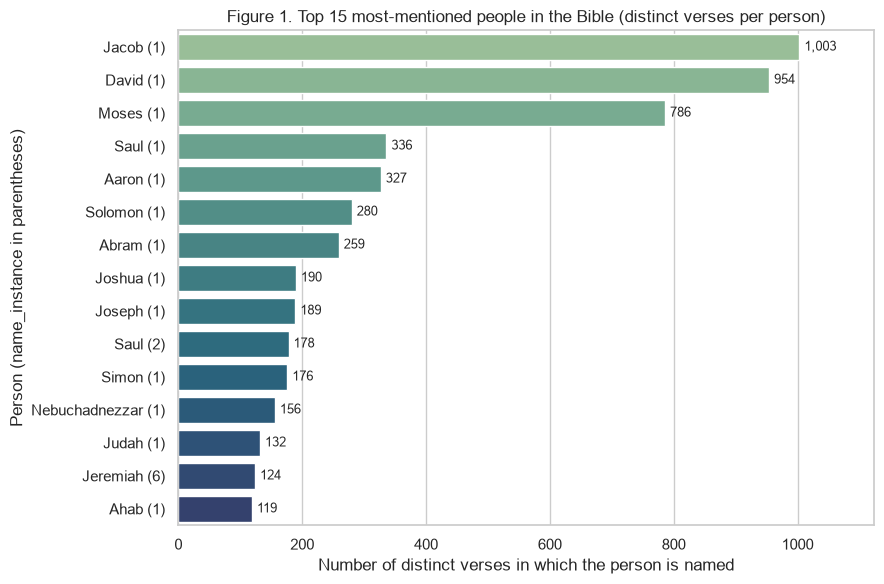

In [23]:
# Figure 1 — Top 15 most-mentioned people (distinct verses), YHVH excluded
fig, ax = plt.subplots(figsize=(9, 6))
labels = top15["person_name"] + " (" + top15["person_id"].str.split("_").str[-1] + ")"
sns.barplot(x=top15["n_verses"], y=labels, hue=labels, legend=False, palette="crest", ax=ax)
for i, v in enumerate(top15["n_verses"]):
    ax.text(v + 8, i, f"{v:,}", va="center", fontsize=9)
ax.set_title("Figure 1. Top 15 most-mentioned people in the Bible (distinct verses per person)")
ax.set_xlabel("Number of distinct verses in which the person is named")
ax.set_ylabel("Person (name_instance in parentheses)")
ax.set_xlim(0, top15["n_verses"].max() * 1.12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_top_people.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure 1 interpretation.** Jacob (1,003 verses), David (954) and Moses (786) lead by a wide margin; the fourth place, Saul (336), has less than half of Moses's count. Thirteen of the 15 are Old Testament figures; the two New Testament figures are the apostle Paul (`Saul_2`, 178 verses, 10th) and Peter (`Simon_1`, 176 verses, 11th), all of whose verses are in the New Testament. The chart is entirely male: no woman reaches the top 15 (the most-mentioned woman, Sarai, appears in 48 verses). The name Saul appears twice with different `name_instance` values (Saul the king and Saul/Paul), which is exactly why the analysis is keyed on `person_id` rather than on the name.

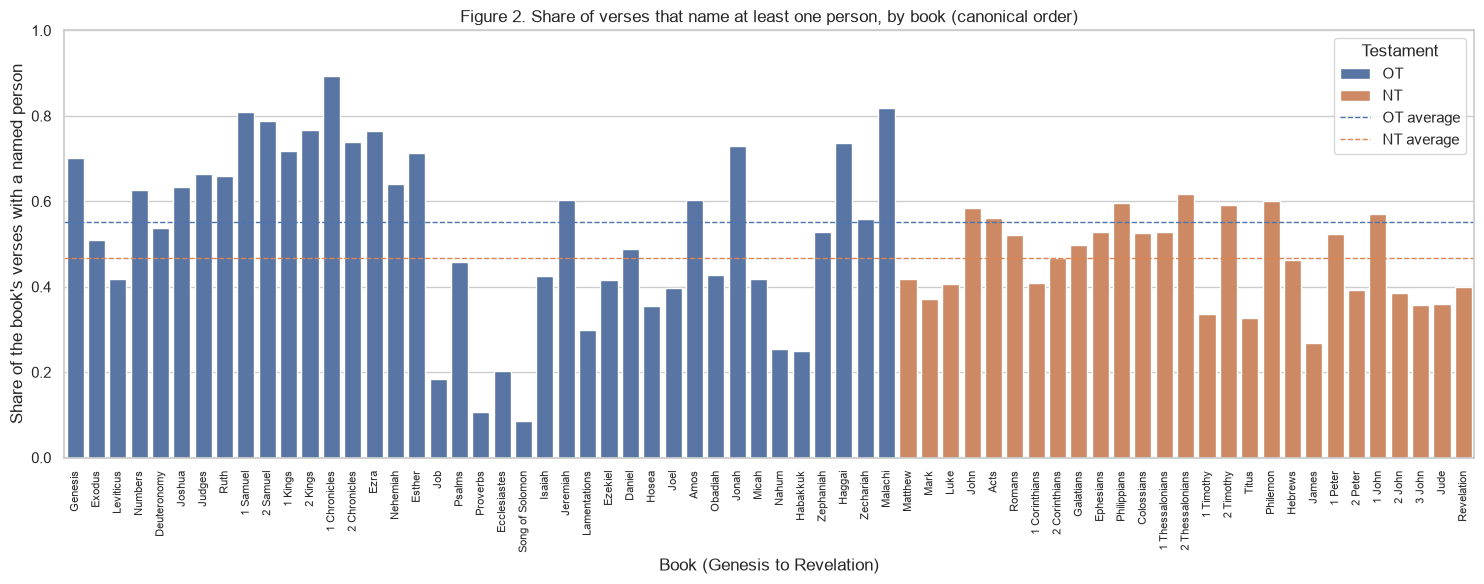

In [24]:
# Figure 2 — Share of verses that name at least one person, per book, in canonical order
fig, ax = plt.subplots(figsize=(15, 6))
palette = {"OT": "#4C72B0", "NT": "#DD8452"}
sns.barplot(data=coverage, x="book_name", y="share_tagged", hue="testament", palette=palette, dodge=False, ax=ax)
ax.axhline(by_testament.loc["OT", "share_tagged"], color=palette["OT"], ls="--", lw=1, label="OT average")
ax.axhline(by_testament.loc["NT", "share_tagged"], color=palette["NT"], ls="--", lw=1, label="NT average")
ax.set_title("Figure 2. Share of verses that name at least one person, by book (canonical order)")
ax.set_xlabel("Book (Genesis to Revelation)")
ax.set_ylabel("Share of the book's verses with a named person")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.legend(title="Testament")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_book_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure 2 interpretation.** Coverage is driven by literary genre more than by testament. Narrative and genealogical books sit at the top: 1 Chronicles names someone in 89 % of its verses (and 1,323 distinct people), followed by 1 Samuel (81 %), 2 Samuel (79 %) and 2 Kings (77 %). Wisdom and poetic books sit at the bottom: Song of Solomon (9 %), Proverbs (11 %), Job (18 %) and Ecclesiastes (20 %) rarely name anyone. On average the Old Testament names a person in 55 % of its verses and the New Testament in 47 %; inside the New Testament the spread is narrower, from James (27 %) up to 2 Thessalonians (62 %) and Philippians (60 %). For question writing this means that "who" questions are naturally abundant in the historical books and scarce in Proverbs or Psalms, where questions must be about images and ideas instead.

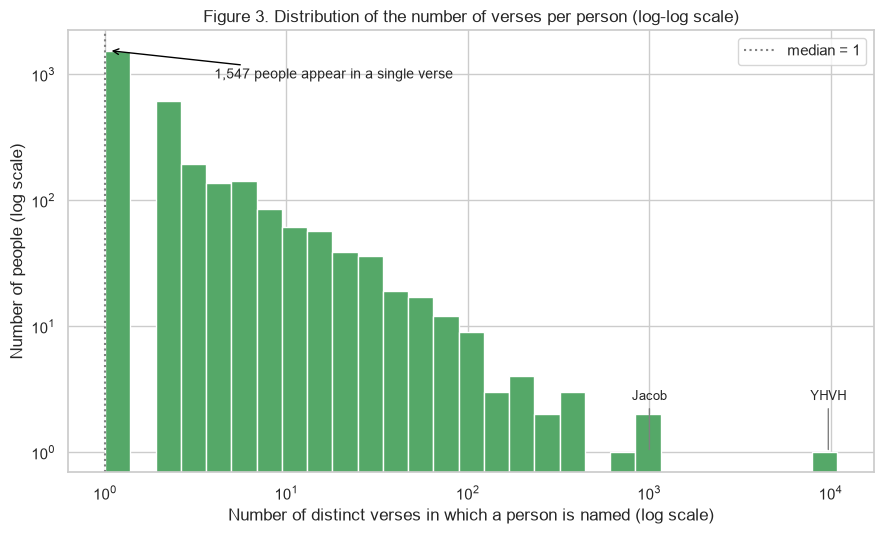

In [25]:
# Figure 3 — Distribution of verses per person (long tail), log-spaced bins
fig, ax = plt.subplots(figsize=(9, 5.5))
bins = np.logspace(0, np.log10(mentions["n_verses"].max()) + 0.05, 30)
ax.hist(mentions["n_verses"], bins=bins, color="#55A868", edgecolor="white")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Figure 3. Distribution of the number of verses per person (log-log scale)")
ax.set_xlabel("Number of distinct verses in which a person is named (log scale)")
ax.set_ylabel("Number of people (log scale)")
one = int((mentions["n_verses"] == 1).sum())
ax.annotate(f"{one:,} people appear in a single verse", xy=(1.05, one), xytext=(4, one * 0.6),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)
ax.axvline(mentions["n_verses"].median(), color="gray", ls=":", label=f"median = {mentions['n_verses'].median():.0f}")
for pid in ("Jacob_1", "YHVH_1"):
    v = int(mentions.loc[mentions.person_id == pid, "n_verses"].iloc[0])
    ax.annotate(pid.split("_")[0], xy=(v, 1), xytext=(v, 2.6), ha="center", fontsize=9, arrowprops=dict(arrowstyle="-", color="gray"))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_mentions_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure 3 interpretation.** The distribution is extremely skewed. Of the 2,993 people with at least one mention, 1,547 (52 %) appear in exactly one verse and 2,362 (79 %) in three or fewer, while only 51 people reach 50 verses and 22 reach 100. The mean (9.2 verses) is nine times the median (1) because a handful of characters carry most of the mentions: the top 10 entries hold 52 % of all person–verse pairs. Both axes are logarithmic: on a linear scale everything collapses into the first bar and the two isolated entries at the far right (Jacob with 1,003 verses and YHVH with 9,717) would be invisible. For a trivia application this long tail is the pool of rare names that make genuinely hard questions, whereas the head of the distribution is the material for beginner questions.

## 6. Summary and Interpretation

**What I learned from the dataset.** BibleData is a person–verse index rather than a text corpus: after removing the 14,733 placeholder rows and collapsing repeated labels it contains 27,399 person–verse pairs linking 2,993 people to 16,484 verses of the 66 books. Mentions are concentrated in a few characters (Jacob, David and Moses account for more than 2,700 verses between them, and the top 10 entries hold 52 % of all pairs) while 1,547 people are named in a single verse. Who gets named depends on genre: genealogies and histories such as 1 Chronicles or 1 Samuel name a person in more than 80 % of their verses, while Song of Solomon, Proverbs, Job and Ecclesiastes name almost nobody. The Old Testament covers 2,723 distinct people and the New Testament 385, with only 115 in both.

**Patterns and insights.** Book length explains the number of verses that name someone (Pearson r = 0.92 between `verse_count` and `tagged_verses`) but not the number of distinct people (r = 0.31): 1 Chronicles is not the longest book, yet it introduces 1,323 people because it is mostly genealogy. The chapter view (Genesis 24) shows why an index like this is valuable: a verse can describe an action ("she emptied her pitcher") without naming the actor, and the chapter-level list recovers Rebekah as the person in the scene, together with the other people who can serve as distractors.

**Limitations and assumptions.** The tables are a curated interpretation of the text, not the text itself: the tagging follows the dataset author's decisions about who is meant in each verse, `YHVH` is tagged as a person, and the canon is the 66-book Protestant one. Names are in English and follow the dataset's spelling (Abram rather than Abraham, Sarai rather than Sarah, Hadassah for Esther), so counts per person depend on how name changes were resolved into a single `person_id`. `tribe` is unknown for 46.6 % of people and `sex` is a binary field. I assumed that `christian_sequence` 1–39 is the Old Testament and that one row per (person, verse) is the right unit; multiple labels of the same person in one verse were collapsed on purpose.

**Surprising or unclear.** The dominance of Jacob over David and Moses was unexpected, and it is explained by the dataset tagging the nation "Israel" as a label of Jacob: 750 of his 1,003 verses carry the label "Israel" and only 243 the label "Jacob" (see the label counts in Section 4), so his count mixes the patriarch with the people named after him; a question writer should treat that entry with care. It was also unclear at first what the `__NA` rows meant; only after checking that they carry no label at all did it become clear they are verse placeholders and not corrupted records.